<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/Day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# ==========================================
# 1. SCALAR MULTIPLICATION
# ==========================================
print("--- 1. SCALAR MULTIPLICATION ---")

scalar_1 = np.array(3)
scalar_2 = np.array(2)

print(scalar_1* scalar_2)



# ==========================================
# 2. VECTOR MULTIPLICATION
# ==========================================
print("\n--- 2. VECTOR MULTIPLICATION ---")
v1 = np.array([2, 4, 6])
v2 = np.array([1, 0, -1])

print("Element-wise (v1 * v2):", v1 * v2)


print("Dot Product (v1 @ v2): ", np.dot(v1, v2))


# ==========================================
# 3. MATRIX MULTIPLICATION
# ==========================================
print("\n--- 3. MATRIX MULTIPLICATION ---")
m1 = np.array([[1, 2],
               [3, 4]])

m2 = np.array([[2, 0],
               [1, 2]])

print("Element-wise Multiplication (m1 * m2):\n", m1 * m2)


print("True Matrix Multiplication (m1 @ m2):\n", m1 @ m2)


# ==========================================
# 4. THE SYMMETRIC MATRIX PROOF
# ==========================================
print("\n--- 4. SYMMETRIC MATRIX PROOF ---")


sym_matrix = np.array([[ 1, -5,  3],
                       [-5,  4,  2],
                       [ 3,  2,  6]])
print("Original Matrix:\n", sym_matrix)

transposed_matrix = sym_matrix.T
print(transposed_matrix)


is_symmetric = np.array_equal(sym_matrix, transposed_matrix)
print(is_symmetric)


is_transposed_symmetric = np.array_equal(transposed_matrix, transposed_matrix.T)
print(is_transposed_symmetric)

--- 1. SCALAR MULTIPLICATION ---
6

--- 2. VECTOR MULTIPLICATION ---
Element-wise (v1 * v2): [ 2  0 -6]
Dot Product (v1 @ v2):  -4

--- 3. MATRIX MULTIPLICATION ---
Element-wise Multiplication (m1 * m2):
 [[2 0]
 [3 8]]
True Matrix Multiplication (m1 @ m2):
 [[ 4  4]
 [10  8]]

--- 4. SYMMETRIC MATRIX PROOF ---
Original Matrix:
 [[ 1 -5  3]
 [-5  4  2]
 [ 3  2  6]]

Transposed Matrix (It looks exactly the same!):
 [[ 1 -5  3]
 [-5  4  2]
 [ 3  2  6]]

Is Original == Transposed? : True
Is the Transposed matrix ALSO symmetric? : True


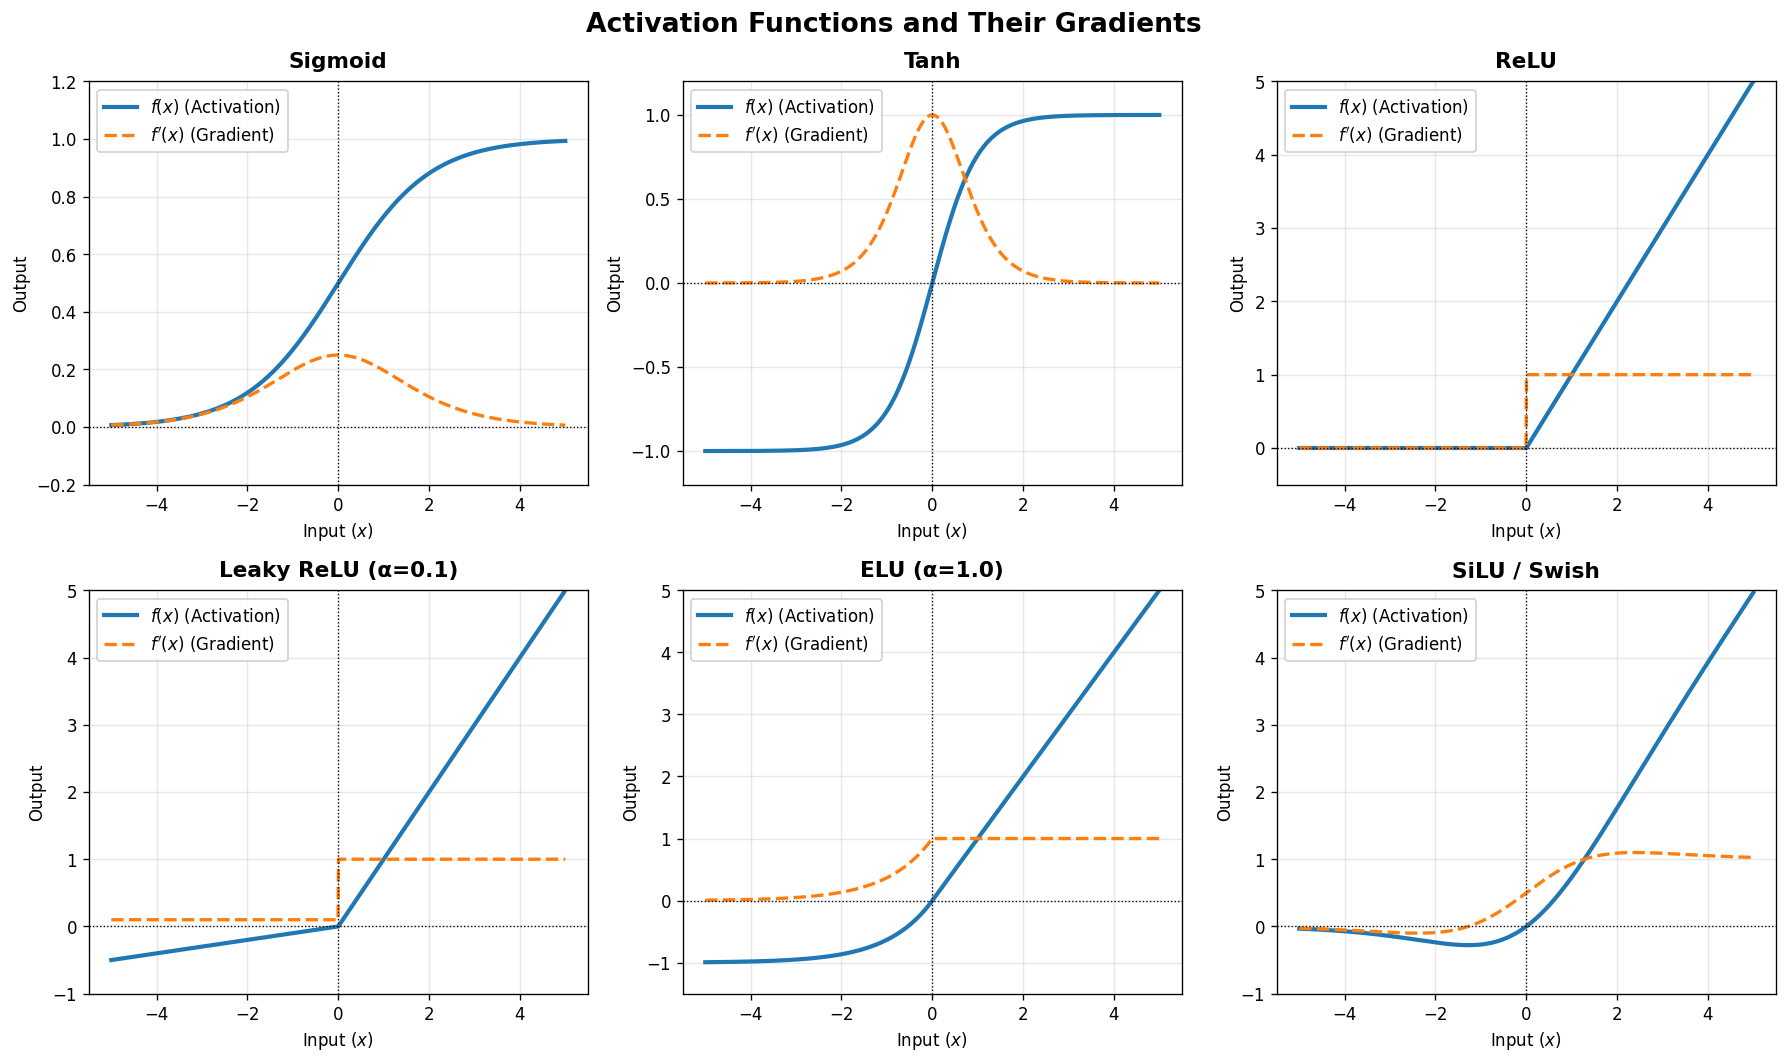

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Activation Functions and Their Analytical Gradients
# ---------------------------------------------------------

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_grad(x):
    return 1.0 - np.tanh(x) ** 2

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return np.where(x > 0, 1.0, 0.0)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_grad(x, alpha=0.1):
    return np.where(x > 0, 1.0, alpha)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_grad(x, alpha=1.0):
    return np.where(x > 0, 1.0, alpha * np.exp(x))

def silu(x):  # Also known as Swish
    return x * sigmoid(x)

def silu_grad(x):
    s = sigmoid(x)
    return s + x * s * (1.0 - s)


# ---------------------------------------------------------
# 2. Data Preparation & Visualization Setup
# ---------------------------------------------------------

x = np.linspace(-5, 5, 1000)

functions = [
    ("Sigmoid", sigmoid, sigmoid_grad, (-0.2, 1.2)),
    ("Tanh", tanh, tanh_grad, (-1.2, 1.2)),
    ("ReLU", relu, relu_grad, (-0.5, 5.0)),
    ("Leaky ReLU (α=0.1)", leaky_relu, leaky_relu_grad, (-1.0, 5.0)),
    ("ELU (α=1.0)", elu, elu_grad, (-1.5, 5.0)),
    ("SiLU / Swish", silu, silu_grad, (-1.0, 5.0)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), dpi=120)
axes = axes.flatten()

for idx, (name, fn, fn_grad, ylim) in enumerate(functions):
    ax = axes[idx]

    # Plot Function and Derivative
    y = fn(x)
    dy = fn_grad(x)

    ax.plot(x, y, label=r"$f(x)$ (Activation)", color="#1f77b4", linewidth=2.5)
    ax.plot(x, dy, label=r"$f'(x)$ (Gradient)", color="#ff7f0e", linewidth=2.0, linestyle="--")

    # Reference Axes and Grids
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(name, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Input ($x$)", fontsize=10)
    ax.set_ylabel("Output", fontsize=10)
    ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", framealpha=0.9)

plt.suptitle("Activation Functions and Their Gradients", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()